In [169]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import  TSNE
from sklearn.decomposition import PCA
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_fscore_support
import cv2
import mediapipe as mp

In [170]:
df = pd.read_csv("hand_landmarks_data.csv")

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

In [172]:
df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


## No Missing Values

In [173]:
df.isna().sum(axis=1).sum()

np.int64(0)

In [174]:
df.iloc[0]

x1       262.669968
y1       257.304901
z1             -0.0
x2       257.417542
y2       247.109055
            ...    
z20       -0.024577
x21      208.006393
y21      259.608673
z21       -0.026722
label          call
Name: 0, Length: 64, dtype: object

## CLasses Are Balanced

<Axes: xlabel='label', ylabel='count'>

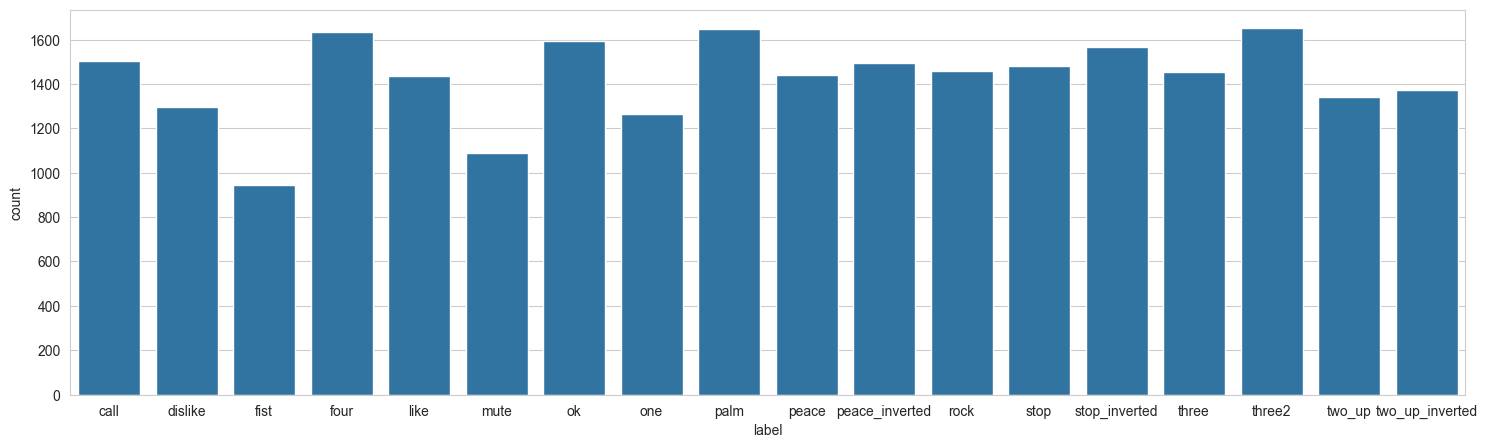

In [175]:
plt.figure(figsize=(18, 5))
sns.countplot(x="label", data=df)

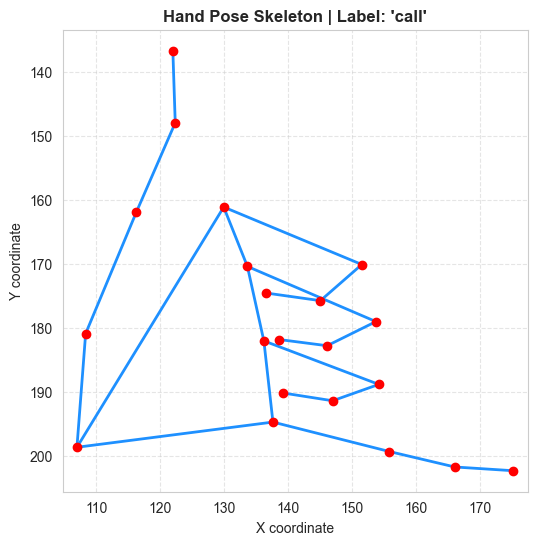

In [176]:
def plot_hand_skeleton(row):
    try:
        x_coords = [row[f'x{i}'] for i in range(1, 22)]
        y_coords = [row[f'y{i}'] for i in range(1, 22)]
    except KeyError as e:
        print(f"Missing coordinate column: {e}")
        return
    connections = [
        (0, 1), (1, 2), (2, 3), (3, 4),         # Thumb
        (0, 5), (5, 6), (6, 7), (7, 8),         # Index finger
        (5, 9), (9, 10), (10, 11), (11, 12),    # Middle finger
        (9, 13), (13, 14), (14, 15), (15, 16),  # Ring finger
        (13, 17), (17, 18), (18, 19), (19, 20), # Pinky
        (0, 17)                                 # Wrist to Pinky base
    ]

    plt.figure(figsize=(6, 6))

    plt.scatter(x_coords, y_coords, color='red', zorder=5)

    for (i, j) in connections:
        plt.plot(
            [x_coords[i], x_coords[j]],
            [y_coords[i], y_coords[j]],
            color='dodgerblue', linewidth=2, zorder=4
        )

    plt.gca().invert_yaxis()

    label = row.get('label', 'Unknown')
    plt.title(f"Hand Pose Skeleton | Label: '{label}'", fontweight='bold')
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.axis('equal')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.show()

sample_row = df.iloc[900]
plot_hand_skeleton(sample_row)

In [177]:
def normalize_hand_landmarks(row):
    coords = np.zeros((21, 3))
    for i in range(1, 22):
        coords[i-1] = [row[f'x{i}'], row[f'y{i}'], row[f'z{i}']]

    wrist = coords[0].copy()
    coords = coords - wrist
    mid_finger_tip = coords[12]
    scale_factor = np.linalg.norm(mid_finger_tip[:2])
    if scale_factor > 0:
        coords = coords / scale_factor
    normalized_row = row.copy()
    for i in range(1, 22):
        normalized_row[f'x{i}'] = coords[i-1, 0]
        normalized_row[f'y{i}'] = coords[i-1, 1]
        normalized_row[f'z{i}'] = coords[i-1, 2]
    return normalized_row

# normalized_sample = normalize_hand_landmarks(sample_row)

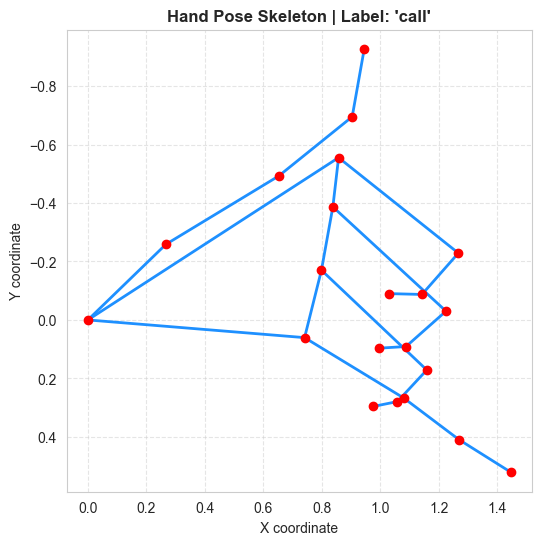

In [178]:
df_normalized = df.apply(normalize_hand_landmarks, axis=1)
plot_hand_skeleton(df_normalized.iloc[1000])

### Some Feature Engineering

In [179]:
TIP_IDS = {
    "thumb": 4,
    "index": 8,
    "middle": 12,
    "ring": 16,
    "pinky": 20
}
ADJACENT_PAIRS = [
    ("thumb", "index"),
    ("index", "middle"),
    ("middle", "ring"),
    ("ring", "pinky")
]
TIP_IDS_ME = {
    "thumb": 1,
    "index": 5,
    "middle": 9,
    "ring": 13,
    "pinky": 17
}
FINGER_JOINTS = {
    "thumb": [1, 2, 3, 4],
    "index": [5, 6, 7, 8],
    "middle": [9, 10, 11, 12],
    "ring": [13, 14, 15, 16],
    "pinky": [17, 18, 19, 20]
}

In [180]:
def compute_distance(row, i, j):
    p1 = np.array([row[f"x{i}"], row[f"y{i}"], row[f"z{i}"]])
    p2 = np.array([row[f"x{j}"], row[f"y{j}"], row[f"z{j}"]])
    return np.linalg.norm(p1 - p2)

In [181]:
def add_adjacent_distances(df):
    for f1, f2 in ADJACENT_PAIRS:
        i = TIP_IDS[f1]
        j = TIP_IDS[f2]
        feature_name = f"{f1}_{f2}_dist"
        df[feature_name] = df.apply(lambda row: compute_distance(row, i, j), axis=1)
        # Second part
        i = TIP_IDS_ME[f1]
        j = TIP_IDS_ME[f2]
        feature_name = f"{f1}_{f2}_dist_ME"
        df[feature_name] = df.apply(lambda row: compute_distance(row, i, j), axis=1)
    for finger, joints in FINGER_JOINTS.items():
        df[f"{finger}_avg_x"] = df[[f"x{i}" for i in joints]].mean(axis=1)
        df[f"{finger}_avg_y"] = df[[f"y{i}" for i in joints]].mean(axis=1)
        df[f"{finger}_avg_z"] = df[[f"z{i}" for i in joints]].mean(axis=1)
    z_cols = [f"z{i}" for i in range(1, 22)]
    # 2. Compute average per row
    df["avg_z"] = df[z_cols].mean(axis=1)
    return df

In [182]:
df_normalized = add_adjacent_distances(df_normalized)

In [183]:
df_normalized.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,middle_avg_x,middle_avg_y,middle_avg_z,ring_avg_x,ring_avg_y,ring_avg_z,pinky_avg_x,pinky_avg_y,pinky_avg_z,avg_z
0,0.0,0.0,0.0,-0.169097,-0.328246,0.000136,-0.508248,-0.501843,0.000187,-0.846234,...,-1.047051,-0.141810,-0.000297,-1.040222,0.001693,-0.000509,-1.167231,0.033494,-0.000655,-0.000303
1,0.0,0.0,0.0,-0.040618,-0.498120,-0.000316,0.191551,-0.982869,-0.000601,0.349889,...,0.984240,-0.629836,-0.000963,1.060539,-0.373750,-0.000910,1.257093,-0.149585,-0.000940,-0.000845
2,0.0,0.0,0.0,0.172978,-0.420554,-0.000004,0.437913,-0.820949,-0.000218,0.621006,...,1.094756,-0.310430,-0.000602,1.110584,-0.056597,-0.000748,1.262057,0.162946,-0.000876,-0.000599
3,0.0,0.0,0.0,-0.020056,-0.468103,-0.000120,0.070355,-0.911821,-0.000378,0.114792,...,0.903103,-0.683066,-0.000793,0.994048,-0.423009,-0.000841,1.153605,-0.146746,-0.001002,-0.000746
4,0.0,0.0,0.0,-0.009611,-0.482677,-0.000101,0.111650,-1.075914,-0.000284,0.131602,...,0.873553,-0.744890,-0.000738,0.962880,-0.491537,-0.000766,1.169214,-0.325467,-0.000789,-0.000638


In [184]:
df_normalized.describe()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,middle_avg_x,middle_avg_y,middle_avg_z,ring_avg_x,ring_avg_y,ring_avg_z,pinky_avg_x,pinky_avg_y,pinky_avg_z,avg_z
count,25675.0,25675.0,25675.0,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,...,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000
mean,0.0,0.0,0.0,0.014740,-0.139833,-0.000183,0.025192,-0.336521,-0.000314,0.028839,...,0.026499,-0.779456,-0.000526,0.017145,-0.651284,-0.000560,0.008792,-0.532057,-0.000550,-0.000467
std,0.0,0.0,0.0,0.243225,0.217575,0.000240,0.434557,0.425219,0.000382,0.509919,...,0.535303,0.460397,0.000510,0.498328,0.345935,0.000489,0.529448,0.426350,0.000434,0.000429
min,0.0,0.0,0.0,-5.834705,-1.392862,-0.017468,-13.681659,-2.760927,-0.032939,-17.489483,...,-16.643648,-7.868360,-0.042833,-15.935196,-12.957796,-0.043637,-21.740168,-27.646104,-0.037858,-0.038583
25%,0.0,0.0,0.0,-0.156725,-0.209768,-0.000243,-0.266598,-0.534523,-0.000384,-0.291434,...,-0.146028,-0.776300,-0.000613,-0.125417,-0.758733,-0.000647,-0.206785,-0.672314,-0.000635,-0.000541
50%,0.0,0.0,0.0,0.086394,-0.122418,-0.000161,0.087623,-0.301500,-0.000260,0.028274,...,0.013031,-0.750397,-0.000407,0.000757,-0.710411,-0.000453,-0.023092,-0.563973,-0.000467,-0.000378
75%,0.0,0.0,0.0,0.169421,-0.078231,-0.000060,0.299678,-0.227268,-0.000146,0.362566,...,0.180624,-0.712018,-0.000291,0.135168,-0.574117,-0.000335,0.209177,-0.349905,-0.000343,-0.000276
max,0.0,0.0,0.0,1.207385,8.901224,0.000705,1.872273,18.811699,0.000825,2.512387,...,2.692277,1.908216,0.000687,2.104552,1.073393,0.000384,2.404386,1.031785,0.000605,0.000534


In [185]:
df_normalized.drop(columns=['x1', 'y1', 'z1'], inplace=True)

In [186]:
Y  = df_normalized['label']
X  = df_normalized.drop(columns=['label'])

In [187]:
X.head()

,x2,y2,z2,x3,y3,z3,x4,y4,z4,x5,...,middle_avg_x,middle_avg_y,middle_avg_z,ring_avg_x,ring_avg_y,ring_avg_z,pinky_avg_x,pinky_avg_y,pinky_avg_z,avg_z
0,-0.169097,-0.328246,0.000136,-0.508248,-0.501843,0.000187,-0.846234,-0.510307,0.000189,-1.049310,...,-1.047051,-0.141810,-0.000297,-1.040222,0.001693,-0.000509,-1.167231,0.033494,-0.000655,-0.000303
1,-0.040618,-0.498120,-0.000316,0.191551,-0.982869,-0.000601,0.349889,-1.343706,-0.000833,0.316538,...,0.984240,-0.629836,-0.000963,1.060539,-0.373750,-0.000910,1.257093,-0.149585,-0.000940,-0.000845
2,0.172978,-0.420554,-0.000004,0.437913,-0.820949,-0.000218,0.621006,-1.149655,-0.000462,0.606619,...,1.094756,-0.310430,-0.000602,1.110584,-0.056597,-0.000748,1.262057,0.162946,-0.000876,-0.000599
3,-0.020056,-0.468103,-0.000120,0.070355,-0.911821,-0.000378,0.114792,-1.259663,-0.000637,0.075864,...,0.903103,-0.683066,-0.000793,0.994048,-0.423009,-0.000841,1.153605,-0.146746,-0.001002,-0.000746
4,-0.009611,-0.482677,-0.000101,0.111650,-1.075914,-0.000284,0.131602,-1.507539,-0.000469,-0.019465,...,0.873553,-0.744890,-0.000738,0.962880,-0.491537,-0.000766,1.169214,-0.325467,-0.000789,-0.000638


In [188]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(Y)

### Just Train/Test as we use cross validation in grid search

In [192]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2)

In [ ]:
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.fit_transform(X_test)

In [ ]:
# param_grid = {
#     "n_estimators": [125, 128, 135],
#     "max_depth" : [45, 50, 55, 60]
# }
#
# grid_search = GridSearchCV(
#     estimator=RandomForestClassifier(),
#     param_grid=param_grid,
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1
# )
#
# grid_search.fit(X_train, y_train)
#
#
#
# print(f"Best Parameters: {grid_search.best_params_}")
# print(f"Best Score: {grid_search.best_score_:.4f}")
# print(f"Test Accuracy: {grid_search.score(X_test, y_test):.4f}")

In [ ]:
# RandomForestClassifier

# Best Parameters: {'max_depth': 55, 'n_estimators': 125}
# Best Score: 0.9766
# Accuracy: 0.9798

# Best Parameters: {'max_depth': 50, 'n_estimators': 128}
# Best Score: 0.9767
# Accuracy: 0.9778

# Best Parameters: {'max_depth': 35, 'n_estimators': 120}
# Best Score: 0.9759
# Accuracy: 0.9757
#
# Best Parameters: {'max_depth': 25, 'n_estimators': 100}
# Best Score: 0.9736
# Accuracy: 0.9768

In [ ]:
models_and_grids = {
    "SVM": {
        "model": SVC(random_state=42),
        "params": {
            'kernel': ['rbf'],
            'C': [350, 375, 400],
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [150, 200, 300],
            "max_depth": [50, 80, 100, None],
        }
    },
    "XGBoost": {
        "model": XGBClassifier(eval_metric='mlogloss', random_state=42),
        "params": {
            'n_estimators': [300, 350],
            'max_depth': [5],
            'learning_rate': [0.2,0.3],
        }
    }
}
scoring_metrics = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, average='macro'),
    "recall": make_scorer(recall_score, average='macro'),
    "f1": make_scorer(f1_score, average='macro'),
}
best_estimators = {}

for name, config in models_and_grids.items():
    print(f"\n==============================")
    print(f"Running Grid Search for: {name}")
    print(f"==============================")

    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        scoring=scoring_metrics,
        refit="accuracy",
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)


    print(f"\n Best Parameters for {name}:")
    print(grid_search.best_params_)

    print(f"Best Cross-Validation: {grid_search.best_score_:.4f}")

    best_estimators[name] = grid_search.best_estimator_
    results = pd.DataFrame(grid_search.cv_results_)
    metric_cols = [c for c in results.columns if "mean_test" in c]
    print("\nAll CV Scoring Metrics:")
    print(results[["params"] + metric_cols])

In [ ]:
# Running Grid Search for: XGBoost
# ==============================
# Fitting 5 folds for each of 27 candidates, totalling 135 fits
#
#  Best Parameters for XGBoost:
# {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}
#  Best Cross-Validation F1 (refit metric): 0.9858

# ==============================
# Running Grid Search for: RandomForest
# ==============================
# Fitting 5 folds for each of 24 candidates, totalling 120 fits
#
#  Best Parameters for RandomForest:
# {'max_depth': 50, 'n_estimators': 300}
#  Best Cross-Validation F1 (refit metric): 0.9835

# --- Running Grid Search for SVM ---
# Fitting 5 folds for each of 4 candidates, totalling 20 fits
# Best Parameters for SVM: {'C': 247, 'gamma': 'scale', 'kernel': 'rbf'}
# Best Cross-Validation Accuracy: 0.9856
#
# --- Final  Set Evaluation ---
# SVM Final  Accuracy: 0.9866

# --- Running Grid Search for SVM ---
# Fitting 5 folds for each of 4 candidates, totalling 20 fits
# Best Parameters for SVM: {'C': 248, 'gamma': 'scale', 'kernel': 'rbf'}
# Best Cross-Validation Accuracy: 0.9861
#
# --- Final  Set Evaluation ---
# SVM Final  Accuracy: 0.9871
# --- Running Grid Search for SVM ---
# Fitting 5 folds for each of 3 candidates, totalling 15 fits
# Best Parameters for SVM: {'C': 250, 'gamma': 'scale', 'kernel': 'rbf'}
# Best Cross-Validation Accuracy: 0.9860
#
# --- Final Set Evaluation ---
# SVM Final  Accuracy: 0.9873

# Best Parameters for SVM: {'C': 35, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
# Best Cross-Validation Accuracy: 0.9822
#
# --- Final  Set Evaluation ---
# SVM Final  Accuracy: 0.9847

In [ ]:
# --- Running Grid Search for XGBoost ---
# Fitting 5 folds for each of 8 candidates, totalling 40 fits
# Best Parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 260}
# Best Cross-Validation Accuracy: 0.9814
# --- Final  Set Evaluation ---
# XGBoost Final  Accuracy: 0.9839

# --- Running Grid Search for XGBoost ---
# Fitting 5 folds for each of 6 candidates, totalling 30 fits
# Best Parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 240}
# Best Cross-Validation Accuracy: 0.9814
# --- Final  Set Evaluation ---
# XGBoost Final  Accuracy: 0.9839

#### SVM is the Best one overall

In [194]:
X_train_set, X_validation, y_train_set, y_validation = train_test_split(X_train, y_train, test_size=0.2)

In [195]:
svm = SVC(C= 375, kernel = 'rbf').fit(X_train_set, y_train_set)

In [196]:
RandomForest = RandomForestClassifier(max_depth=50, n_estimators = 300).fit(X_train_set, y_train_set)

In [197]:
xgboost = XGBClassifier(max_depth=5, n_estimators = 300).fit(X_train_set, y_train_set)

In [201]:
svm_pred = svm.predict(X_validation)
tree_pred = RandomForest.predict(X_validation)
xgboost_pred = xgboost.predict(X_validation)

In [203]:
svm_precision, svm_recall, svm_f1, _ = precision_recall_fscore_support(y_validation, svm_pred, average='macro')
tree_precision, tree_recall, tree_f1, _ = precision_recall_fscore_support(y_validation, tree_pred, average='macro')
xgb_precision, xgb_recall, xgb_f1, _ = precision_recall_fscore_support(y_validation, xgboost_pred, average='macro')

metrics_summary = pd.DataFrame({
    "Precision": [svm_precision, tree_precision, xgb_precision],
    "Recall":    [svm_recall,    tree_recall,    xgb_recall],
    "F1-score":  [svm_f1,        tree_f1,        xgb_f1]
}, index=["SVM", "Decision Tree", "XGBoost"]).round(4)

print(metrics_summary)

               Precision  Recall  F1-score
SVM               0.9880  0.9881    0.9879
Decision Tree     0.9850  0.9847    0.9848
XGBoost           0.9844  0.9843    0.9843


**=> SVM is the Best model to fit such data, with its rbf kernel model**

*We Cannot Take Descion based on test Data (\*_-) Just before Release!*

In [210]:
print("SVM =>           ", svm.score(X_test, y_test)*100)
print("XGBoost =>       " , xgboost.score(X_test, y_test)*100)
print("Random Forest => ", RandomForest.score(X_test, y_test)*100)

SVM =>            98.8510223953262
XGBoost =>        98.61733203505355
Random Forest =>  98.28627069133398


In [165]:
def prepare_features_for_model(raw_landmark_data):
    df_row = pd.DataFrame([raw_landmark_data])
    df_normalized = df_row.apply(normalize_hand_landmarks, axis=1)
    df_features = add_adjacent_distances(df_normalized)
    df_features.drop(columns=['x1', 'y1', 'z1'], inplace=True, errors='ignore')
    final_features = df_features[X.columns]
    return final_features

In [166]:
def predict_gesture(normalized_dict):
    processed_features = prepare_features_for_model(normalized_dict)
    prediction_encoded = svm.predict(processed_features)
    prediction_text = label_encoder.inverse_transform(prediction_encoded)

    return prediction_text[0]

In [190]:
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils
mp_styles = mp.solutions.drawing_styles

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("Could not open webcam.")

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    model_complexity=1,
    min_detection_confidence=0.6,
    min_tracking_confidence=0.6
)

cv2.namedWindow("Hand Gesture (21 landmarks)", cv2.WINDOW_NORMAL)
try:
    while True:
        ok, frame = cap.read()
        if not ok:
            break

        frame = cv2.flip(frame, 1)

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        rgb.flags.writeable = False
        result = hands.process(rgb)
        rgb.flags.writeable = True

        label = "No hand"
        feats_preview = ""

        if result.multi_hand_landmarks:
            hand_landmarks = result.multi_hand_landmarks[0]

            raw_landmark_data = {}
            for i, lm in enumerate(hand_landmarks.landmark):
                raw_landmark_data[f"x{i+1}"] = lm.x
                raw_landmark_data[f"y{i+1}"] = lm.y
                raw_landmark_data[f"z{i+1}"] = lm.z

            label = predict_gesture(raw_landmark_data)

            mp_draw.draw_landmarks(
                frame,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,
                mp_styles.get_default_hand_landmarks_style(),
                mp_styles.get_default_hand_connections_style(),
            )

        cv2.putText(frame, f"Pred: {label}", (10, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)
        if feats_preview:
            cv2.putText(frame, feats_preview, (10, 70),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        cv2.imshow("Hand Gesture (21 landmarks)", frame)
        if cv2.waitKey(1) & 0xFF == 27:
            break
finally:
    hands.close()
    cap.release()
    cv2.destroyAllWindows()